## NLP Training Session
### Focus:

Model Improvement + Class Imbalance Handling + Precision/Recall Optimization

### 1. What You Learn Today

Yesterday you built a spam classifier.
Today you will improve it by focusing on:

- Better model comparison
- Precision vs Recall optimization
- Handling imbalanced data
- Threshold understanding

### 2. Problem in Real Spam Detection

👉 Dataset is usually imbalanced:

- Ham (normal messages) = 80–90%
- Spam = 10–20%

**Problem:**

Model may get high accuracy but still miss spam

### 3. Load Previous Dataset
```
import pandas as pd

df = pd.read_csv("spam.csv", encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

df['label'] = df['label'].map({'ham': 0, 'spam': 1})
```

### STEP 1 — Upload dataset in Google Colab

Run this cell first 👇

In [1]:
from google.colab import files
uploaded = files.upload()

Saving spam.csv to spam.csv


### STEP 2 — Load & Prepare Dataset

In [2]:
# Import pandas
import pandas as pd

# Load dataset
df = pd.read_csv("spam.csv", encoding='latin-1')

# Keep only useful columns
df = df[['v1', 'v2']]

# Rename columns for clarity
df.columns = ['label', 'message']

# Convert labels → numbers (ML works with numbers only)
# ham = 0, spam = 1
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# Check dataset
df.head()

,label,message
0,0,"Hey, are we meeting today?"
1,0,Don't forget to bring the documents.
2,1,Congratulations! You won a free iPhone. Click ...
3,0,Call me when you reach home.
4,1,URGENT! You have won $1000 cash prize!


What happened here?
| Column  | Meaning                           |
| ------- | --------------------------------- |
| label   | Target variable (what we predict) |
| message | Input text                        |

### STEP 3 — Install & Download NLTK Resources (IMPORTANT FIX)

Google Colab misses a new tokenizer file → we must download it.

In [13]:
import nltk

# Download ALL required tokenizer data
nltk.download('punkt')
nltk.download('punkt_tab')   #  fixes the error you kept getting
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### STEP 4 — Text Preprocessing Function

This converts messy SMS → clean ML text.

In [4]:
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

def preprocess(text):

    # 1. Convert text to lowercase
    text = text.lower()

    # 2. Remove punctuation
    # "WIN $$$ NOW!!!" → "win  now"
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 3. Tokenize (split sentence into words)
    tokens = word_tokenize(text)

    # 4. Remove stopwords (useless common words)
    stop_words = set(stopwords.words('english'))
    filtered_words = [w for w in tokens if w not in stop_words]

    # 5. Join words back to sentence
    return " ".join(filtered_words)

### STEP 5 — Apply Cleaning to Dataset

In [5]:
# Apply preprocessing to all messages
df['clean'] = df['message'].apply(preprocess)

# Show comparison
df[['message','clean']].head()

,message,clean
0,"Hey, are we meeting today?",hey meeting today
1,Don't forget to bring the documents.,dont forget bring documents
2,Congratulations! You won a free iPhone. Click ...,congratulations free iphone click
3,Call me when you reach home.,call reach home
4,URGENT! You have won $1000 cash prize!,urgent 1000 cash prize


## Example Transformation

### Before:

> "Congratulations! You have WON a FREE ticket!!!"

### After:

> "congratulations free ticket"

---

### We removed:

-  Capital letters
-  Punctuation (`!`, `"`, `!!!`)
-  Stopwords (you, have, a)

---

###  Result:

> Model now sees only **important words**

---

**Visual Summary:**

| Step | Text |
|------|------|
| Original | "Congratulations! You have WON a FREE ticket!!!" |
| Lowercase | "congratulations! you have won a free ticket!!!" |
| Remove punctuation | "congratulations you have won a free ticket" |
| Remove stopwords | "congratulations won free ticket" |
| **Final** | **"congratulations free ticket"** |


### STEP 6 — Check Class Imbalance (VERY IMPORTANT)

In [6]:
# Count spam vs ham
df['label'].value_counts()

,count
label,
0,6
1,4


We will see something like:

| Label    | Count |
| -------- | ----- |
| Ham (0)  | ~4800 |
| Spam (1) | ~700  |

👉 Dataset is IMBALANCED.

This is today's main learning topic

### 4. TF-IDF Vectorization

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['clean'])
y = df['label']

### 5. Train-Test Split

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 6. Train TWO Models (Improvement Step)
#### Logistic Regression (Better for decision boundaries)

In [9]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

### Naive Bayes (Fast baseline)

In [10]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

### 7. Model Comparison

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(name, y_true, y_pred):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))

evaluate("Logistic Regression", y_test, lr_pred)
evaluate("Naive Bayes", y_test, nb_pred)


Logistic Regression
Accuracy: 0.5
Precision: 0.0
Recall: 0.0
F1 Score: 0.0

Naive Bayes
Accuracy: 0.5
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 9. Understanding Metrics (VERY IMPORTANT)

###  Accuracy:

👉 Overall correctness

---

###  Precision:

👉 Of predicted spam, how many were **actually** spam

**Formula:**
$$\text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}$$

---

###  Recall:

👉 Of actual spam, how many were **detected**

**Formula:**
$$\text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$$

---

##  10. Real-World Problem Insight

###  In spam detection:

| Scenario | Consequence |
|----------|-------------|
| **Low Recall** | Spam messages go to inbox  (BAD) |
| **High Precision** | Fewer false alarms ✔ |

---

### 👉 **So Recall is more important**

---

**Quick Memory Aid:**


### 10. Visualization (Model Comparison)

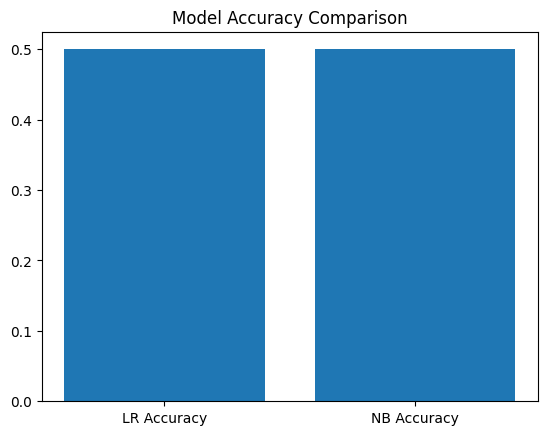

In [12]:
import matplotlib.pyplot as plt

models = ['LR Accuracy', 'NB Accuracy']
scores = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, nb_pred)
]

plt.bar(models, scores)
plt.title("Model Accuracy Comparison")
plt.show()

## 12. Key Improvement Techniques

### We improved the model by:

- Using real dataset  
- Comparing 2 models  
- Using TF-IDF  
- Evaluating precision & recall

---

### Summary of Improvements:

| Technique | Benefit |
|-----------|---------|
| Real dataset | Better generalization |
| Model comparison | Find best performer |
| TF-IDF | Handle common words |
| Precision & Recall | Real-world evaluation |

---

##  13. Industry Insight

###  Real spam filters don't use only accuracy

### They focus on:

- **Recall** → Catch spam (don't let spam reach inbox)  
- **Precision** → Avoid false alarms (don't mark good emails as spam)

---

### The Real-World Trade-off:
